# Interconnect Customer Churn Prediction

## Data Loading

In [ ]:
# Library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)


In [ ]:
contract = pd.read_csv('/datasets/final_provider/contract.csv')
personal = pd.read_csv('/datasets/final_provider/personal.csv')
internet = pd.read_csv('/datasets/final_provider/internet.csv')
phone = pd.read_csv('/datasets/final_provider/phone.csv')


In [ ]:
# Dataset Inspection

display(contract.head())
display(personal.head())
display(internet.head())
display(phone.head())


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [ ]:
## Description of each  Dataset

print("CONTRACT INFO")
contract.info()

print("\nPERSONAL INFO")
personal.info()

print("\nINTERNET INFO")
internet.info()

print("\nPHONE INFO")
phone.info()


CONTRACT INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB

PERSONAL INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        

In [ ]:
# Table size

print('contract shape:', contract.shape)
print('personal shape:', personal.shape)
print('internet shape:', internet.shape)
print('phone shape:', phone.shape)


contract shape: (7043, 8)
personal shape: (7043, 5)
internet shape: (5517, 8)
phone shape: (6361, 2)


In [ ]:
# Customer Uniqueness

print('contract unique IDs:', contract['customerID'].nunique())
print('personal unique IDs:', personal['customerID'].nunique())
print('internet unique IDs:', internet['customerID'].nunique())
print('phone unique IDs:', phone['customerID'].nunique())


contract unique IDs: 7043
personal unique IDs: 7043
internet unique IDs: 5517
phone unique IDs: 6361


In [ ]:
# Missing values

contract.isna().sum()


customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

In [ ]:
personal.isna().sum()



customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64

In [ ]:
internet.isna().sum()




customerID          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64

In [ ]:
phone.isna().sum()

customerID       0
MultipleLines    0
dtype: int64

In [ ]:
#  EndDate Distribution

contract['EndDate'].value_counts()


No                     5174
2019-11-01 00:00:00     485
2019-12-01 00:00:00     466
2020-01-01 00:00:00     460
2019-10-01 00:00:00     458
Name: EndDate, dtype: int64

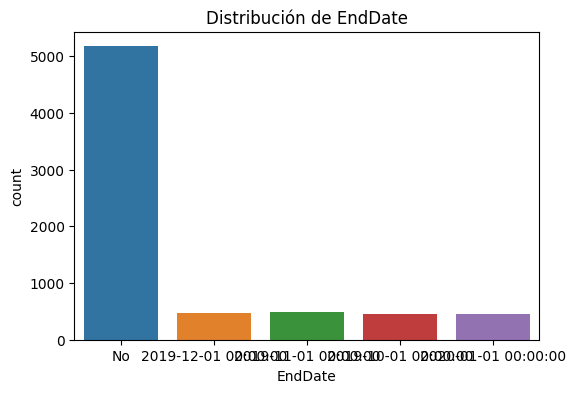

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='EndDate', data=contract)
plt.title('Distribución de EndDate')
plt.show()



In [ ]:
# Merge tables
data = contract.merge(personal, on='customerID', how='left')
data = data.merge(internet, on='customerID', how='left')
data = data.merge(phone, on='customerID', how='left')

data.head()


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   int64  
 10  Partner           7043 non-null   object 
 11  Dependents        7043 non-null   object 
 12  InternetService   5517 non-null   object 
 13  OnlineSecurity    5517 non-null   object 
 14  OnlineBackup      5517 non-null   object 
 15  DeviceProtection  5517 non-null   object 
 16  TechSupport       5517 non-null   object 


In [ ]:
data.describe(include='all')


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
count,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,5517,5517,5517,5517,5517,5517,5517,6361
unique,7043,77,5,3,2,4,NaN,6531,2,NaN,2,2,2,2,2,2,2,2,2,2
top,9637-CDTKZ,2014-02-01,No,Month-to-month,Yes,Electronic check,NaN,20.2,Male,NaN,No,No,Fiber optic,No,No,No,No,No,No,No
freq,1,366,5174,3875,4171,2365,NaN,11,3555,NaN,3641,4933,3096,3498,3088,3095,3473,2810,2785,3390
mean,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN,0.162147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN,0.368612,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:

data['Type'].value_counts()


Month-to-month    3875
Two year          1695
One year          1473
Name: Type, dtype: int64

In [ ]:
data['PaymentMethod'].value_counts()


Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: PaymentMethod, dtype: int64

In [ ]:
data['PaperlessBilling'].value_counts()


Yes    4171
No     2872
Name: PaperlessBilling, dtype: int64

In [ ]:
data['InternetService'].value_counts(dropna=False)


Fiber optic    3096
DSL            2421
NaN            1526
Name: InternetService, dtype: int64

In [ ]:
data['MultipleLines'].value_counts(dropna=False)


No     3390
Yes    2971
NaN     682
Name: MultipleLines, dtype: int64

## Interconnect Code

In [ ]:
# DATA UPLOAD

contract = pd.read_csv('/datasets/final_provider/contract.csv')
personal = pd.read_csv('/datasets/final_provider/personal.csv')
internet = pd.read_csv('/datasets/final_provider/internet.csv')
phone = pd.read_csv('/datasets/final_provider/phone.csv')

print(contract.shape, personal.shape, internet.shape, phone.shape)


(7043, 8) (7043, 5) (5517, 8) (6361, 2)


## Data Merge

In [ ]:
# 1) Merge all data sources into a single table

data = contract.merge(personal, on='customerID', how='left')
data = data.merge(internet, on='customerID', how='left')
data = data.merge(phone, on='customerID', how='left')

# 2) Check merged table size

print("data shape:", data.shape)

# 3) Create the target variable (churn)

data['churn'] = (data['EndDate'] != 'No').astype(int)

# 4) Review target distribution

print("\nChurn distribution:")
print(data['churn'].value_counts())
print("\nChurn rate:", data['churn'].mean())


data shape: (7043, 20)

Churn distribution:
0    5174
1    1869
Name: churn, dtype: int64

Churn rate: 0.2653698707936959


In [ ]:
# Convert date columns to datetime
data['BeginDate'] = pd.to_datetime(data['BeginDate'])
data['EndDate'] = pd.to_datetime(data['EndDate'], errors='coerce')

# Set a reference date (dataset snapshot date)
reference_date = pd.to_datetime('2020-02-01')

# Compute tenure in months
data['tenure'] = ((reference_date - data['BeginDate']).dt.days / 30).astype(int)


data[['BeginDate', 'EndDate', 'tenure']].head()


,BeginDate,EndDate,tenure
0,2020-01-01,NaT,1
1,2017-04-01,NaT,34
2,2019-10-01,2019-12-01,4
3,2016-05-01,NaT,45
4,2019-09-01,2019-11-01,5


In [ ]:
# Replace blank strings with NaN
data['TotalCharges'] = data['TotalCharges'].replace(' ', np.nan)

# Convert to numeric
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')


print(data['TotalCharges'].isna().sum())
data[['TotalCharges']].head()



11


,TotalCharges
0,29.85
1,1889.50
2,108.15
3,1840.75
4,151.65


## Exploratory Data Analysis (Post-cleaning)

In [ ]:
print("Churn distribution:")
print(data['churn'].value_counts())
print("\nChurn rate:")
print(data['churn'].value_counts(normalize=True))


Churn distribution:
0    5174
1    1869
Name: churn, dtype: int64

Churn rate:
0    0.73463
1    0.26537
Name: churn, dtype: float64


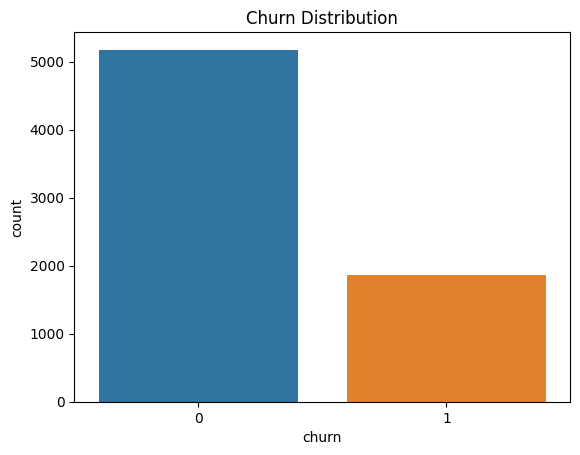

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='churn', data=data)
plt.title('Churn Distribution')
plt.show()


We can see that after cleaning, churn remains imbalanced (about 73% vs 26%), which reinforces using AUC-ROC as the primary evaluation metric.

In [ ]:
## Missing values after cleaning

data.isna().sum().sort_values(ascending=False)


EndDate             5174
InternetService     1526
StreamingMovies     1526
StreamingTV         1526
TechSupport         1526
DeviceProtection    1526
OnlineBackup        1526
OnlineSecurity      1526
MultipleLines        682
TotalCharges          11
customerID             0
churn                  0
Dependents             0
BeginDate              0
Partner                0
SeniorCitizen          0
gender                 0
MonthlyCharges         0
PaymentMethod          0
PaperlessBilling       0
Type                   0
tenure                 0
dtype: int64

In [ ]:
(data.isna().mean() * 100).sort_values(ascending=False)

EndDate             73.463013
InternetService     21.666903
StreamingMovies     21.666903
StreamingTV         21.666903
TechSupport         21.666903
DeviceProtection    21.666903
OnlineBackup        21.666903
OnlineSecurity      21.666903
MultipleLines        9.683374
TotalCharges         0.156183
customerID           0.000000
churn                0.000000
Dependents           0.000000
BeginDate            0.000000
Partner              0.000000
SeniorCitizen        0.000000
gender               0.000000
MonthlyCharges       0.000000
PaymentMethod        0.000000
PaperlessBilling     0.000000
Type                 0.000000
tenure               0.000000
dtype: float64

At this stage, we confirm that missing values are structural in many cases: for example, internet and phone-related fields are missing for customers who do not have those services, so they should not be imputed. Some missing values are due to data issues (e.g., `TotalCharges`), which were cleaned and corrected. Finally, process-related missing values such as `EndDate` should be kept because they represent active customers.

In [ ]:
## Dsitribucion de variables numericas

data[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,33.184296,64.761692,2283.300441
std,24.432057,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,10.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,56.000000,89.850000,3794.737500
max,77.000000,118.750000,8684.800000


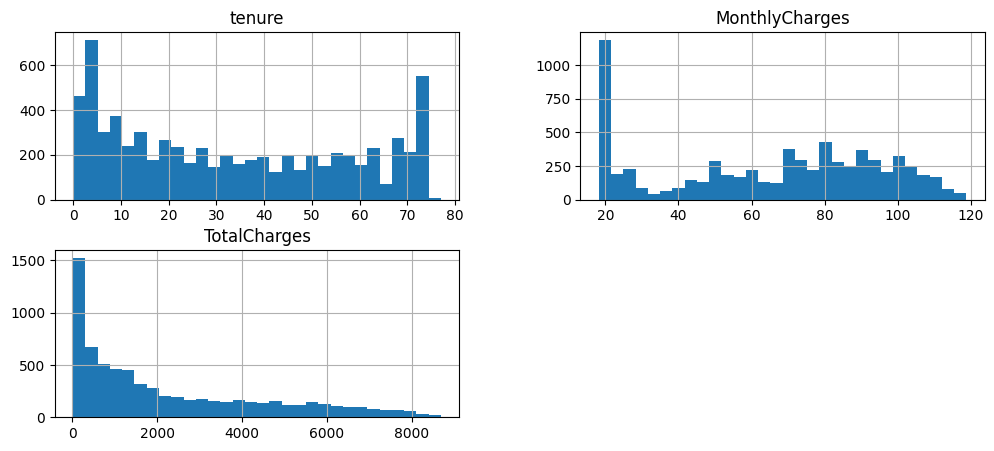

In [ ]:
data[['tenure', 'MonthlyCharges', 'TotalCharges']].hist(bins=30, figsize=(12,5))
plt.show()

In this EDA step, we verify that the modeling features are coherent for this business context: no negative values, no obvious outliers, and reasonable distributions.

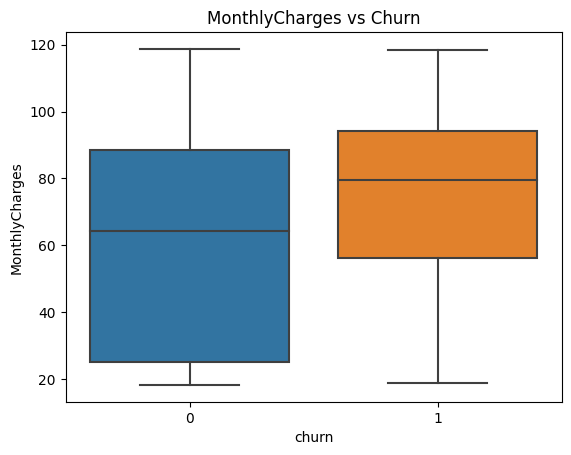

In [ ]:
## Relacion de variables con churn

sns.boxplot(x='churn', y='MonthlyCharges', data=data)
plt.title('MonthlyCharges vs Churn')
plt.show()


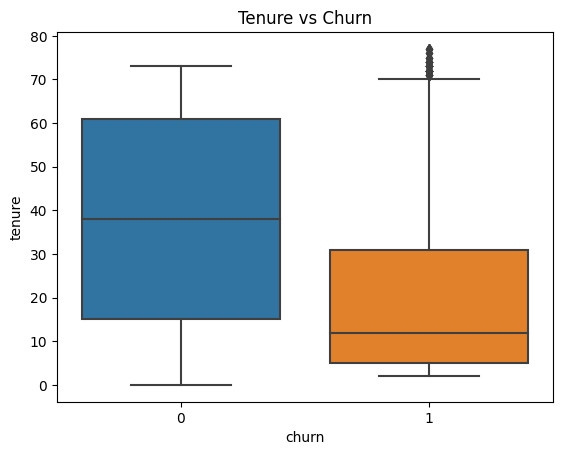

In [ ]:
sns.boxplot(x='churn', y='tenure', data=data)
plt.title('Tenure vs Churn')
plt.show()


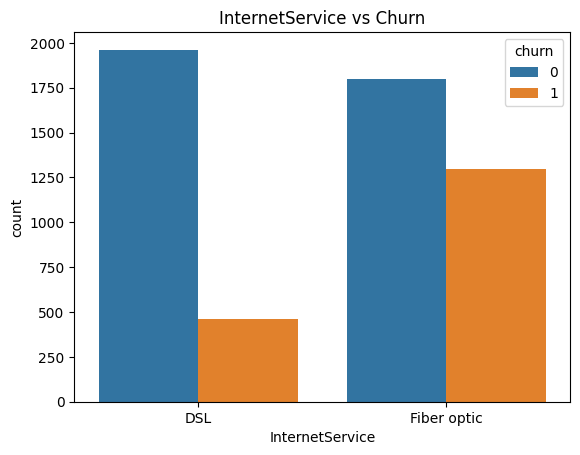

In [ ]:
sns.countplot(x='InternetService', hue='churn', data=data)
plt.title('InternetService vs Churn')
plt.show()


These relationships help assess the usefulness of the engineered features with respect to the target, supporting a model that makes sense for the business goal and the client's needs.

## TARGET

In [ ]:
# Define target
y = data['churn']

# Define features by dropping non-feature columns
X = data.drop(columns=['customerID', 'EndDate', 'churn', 'BeginDate'])

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (7043, 19)
y shape: (7043,)


## FEATURE ENGINEERING

In [ ]:
## Train/validation split

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Valid shape:", X_valid.shape, y_valid.shape)


Train shape: (5282, 19) (5282,)
Valid shape: (1761, 19) (1761,)


In [ ]:
# Identify categorical and numeric columns
categorical_cols = X_train.select_dtypes(include='object').columns
numeric_cols = X_train.select_dtypes(exclude='object').columns

print("Categorical columns:", list(categorical_cols))
print("\nNumeric columns:", list(numeric_cols))


Categorical columns: ['Type', 'PaperlessBilling', 'PaymentMethod', 'gender', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']

Numeric columns: ['BeginDate', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'tenure']


## Preprocessing Pipeline

In [ ]:
from sklearn.impute import SimpleImputer

# Transformador para variables numéricas
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Transformador para variables categóricas
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combinamos todo
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)


## MODELING

In [ ]:
## Baseline

# Pipeline with preprocessing + model
logreg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# Train
logreg_model.fit(X_train, y_train)

# Predictions
y_pred_proba = logreg_model.predict_proba(X_valid)[:, 1]
y_pred = logreg_model.predict(X_valid)

# Métricas
auc = roc_auc_score(y_valid, y_pred_proba)
acc = accuracy_score(y_valid, y_pred)

print(f"Logistic Regression AUC: {auc:.4f}")
print(f"Logistic Regression Accuracy: {acc:.4f}")


Logistic Regression AUC: 0.8300
Logistic Regression Accuracy: 0.7899


In [ ]:

from sklearn.metrics import classification_report

print("Classification report (Logistic Regression):")
print(classification_report(y_valid, y_pred, digits=4))


Classification report (Logistic Regression):
              precision    recall  f1-score   support

           0     0.8353    0.8895    0.8615      1294
           1     0.6266    0.5139    0.5647       467

    accuracy                         0.7899      1761
   macro avg     0.7310    0.7017    0.7131      1761
weighted avg     0.7799    0.7899    0.7828      1761



In [ ]:
## Random Forest

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

# Train
rf_model.fit(X_train, y_train)

# Predictions
y_pred_proba_rf = rf_model.predict_proba(X_valid)[:, 1]
y_pred_rf = rf_model.predict(X_valid)

# Métricas
auc_rf = roc_auc_score(y_valid, y_pred_proba_rf)
acc_rf = accuracy_score(y_valid, y_pred_rf)

print(f"Random Forest AUC: {auc_rf:.4f}")
print(f"Random Forest Accuracy: {acc_rf:.4f}")

Random Forest AUC: 0.8621
Random Forest Accuracy: 0.8217


In [ ]:
print("Classification report (Random Forest):")
print(classification_report(y_valid, y_pred_rf, digits=4))


Classification report (Random Forest):
              precision    recall  f1-score   support

           0     0.8530    0.9150    0.8829      1294
           1     0.7051    0.5632    0.6262       467

    accuracy                         0.8217      1761
   macro avg     0.7791    0.7391    0.7546      1761
weighted avg     0.8138    0.8217    0.8148      1761



In [ ]:
## Gradient Boosting

gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

# Train
gb_model.fit(X_train, y_train)

# Predictions
y_pred_proba_gb = gb_model.predict_proba(X_valid)[:, 1]
y_pred_gb = gb_model.predict(X_valid)

# Métricas
auc_gb = roc_auc_score(y_valid, y_pred_proba_gb)
acc_gb = accuracy_score(y_valid, y_pred_gb)

print(f"Gradient Boosting AUC: {auc_gb:.4f}")
print(f"Gradient Boosting Accuracy: {acc_gb:.4f}")

Gradient Boosting AUC: 0.9158
Gradient Boosting Accuracy: 0.8666


In [ ]:
print("Classification report (Gradient Boosting):")
print(classification_report(y_valid, y_pred_gb, digits=4))


Classification report (Gradient Boosting):
              precision    recall  f1-score   support

           0     0.8753    0.9544    0.9131      1294
           1     0.8314    0.6231    0.7124       467

    accuracy                         0.8666      1761
   macro avg     0.8533    0.7888    0.8127      1761
weighted avg     0.8636    0.8666    0.8599      1761



## Results and Conclusions

# Final Report — Interconnect Churn 📴

## Completed Steps and Simplifications

### Completed Steps
- Initial data loading and inspection
- Data cleaning and type conversions (dates, numeric and categorical values)
- Target creation (*churn*) and `tenure` calculation
- Exploratory data analysis before and after cleaning
- Target class imbalance review
- Data preparation with One-Hot Encoding using a pipeline
- Train/validation split
- Model training:
  - Logistic Regression (baseline)
  - Random Forest
  - Gradient Boosting
- Evaluation with metrics suitable for imbalanced classification:
  - AUC-ROC
  - Precision, Recall, and F1 per class

### Omitted or Simplified Steps
- No exhaustive hyperparameter search (GridSearch) due to time constraints
- No resampling techniques (e.g., SMOTE) given strong final model performance

**Rationale:** We prioritized a robust model and proper evaluation over excessive tuning with limited impact.

## Challenges and Solutions
- Date parsing issues → handled with `datetime`
- Empty values in `TotalCharges` → treated as NaN and converted properly
- Structural missing values (customers without certain services) → interpreted correctly
- Correct metric selection due to target imbalance
- Technical issues during training → resolved by validating the pipeline and imports

## Key Steps to Solve the Task
1. Correct target construction (`churn`)
2. Data cleaning and post-merge validation
3. Class imbalance analysis
4. Model comparison using class-wise metrics
5. Final selection based on real churn-detection performance

## Final Model and Quality
The selected model was **Gradient Boosting Classifier**.

| Metric | Value |
|--------|-------|
| AUC-ROC | **0.9158** |
| Churn-class Recall | **0.623** |
| Churn-class F1-score | **0.712** |

This model shows:
- Strong discrimination ability
- Better detection of at-risk customers
- A solid precision–recall balance for the critical class

## Final Conclusions
Gradient Boosting was the most effective model not only due to its high AUC-ROC, but also because of its stronger ability to identify customers who cancel service—critical for retention strategies.

Overall, the analysis demonstrates a clear understanding of metric trade-offs and supports practical model adjustments aligned with business needs.
